In [1]:
# Name: Bishesh
# Course: MSCS 634
# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis
# Date: November 3, 2025

# Step Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Display all columns
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Step Load Dataset
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

# Display first five rows
df.head()

# Step 3 Data Overview
print("Dataset shape:", df.shape)
df.info()
df.describe()



Dataset shape: (5110, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


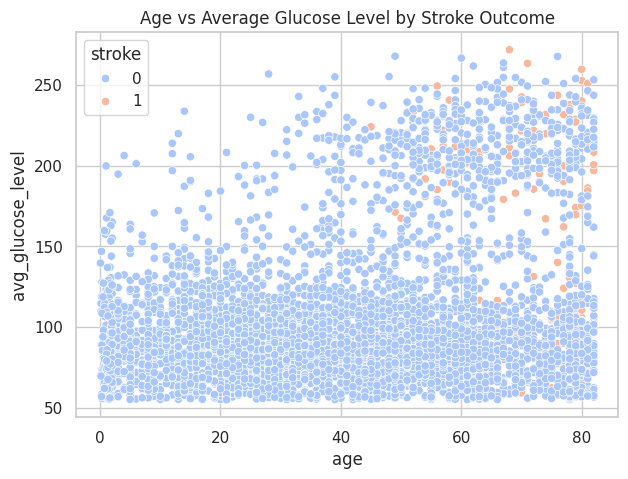

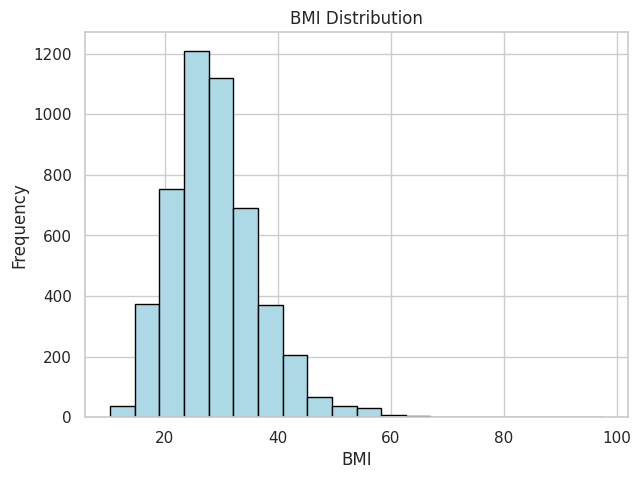

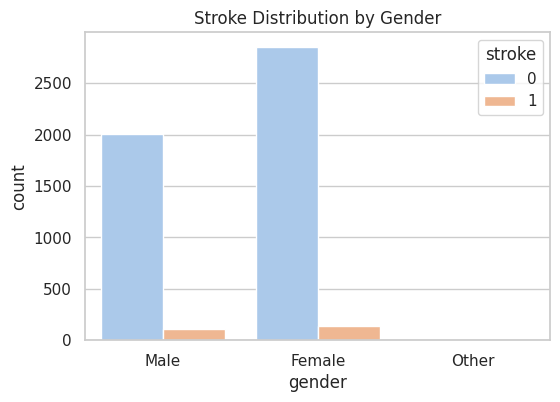

/tmp/ipython-input-1699969136.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y='age', data=df, palette='coolwarm')


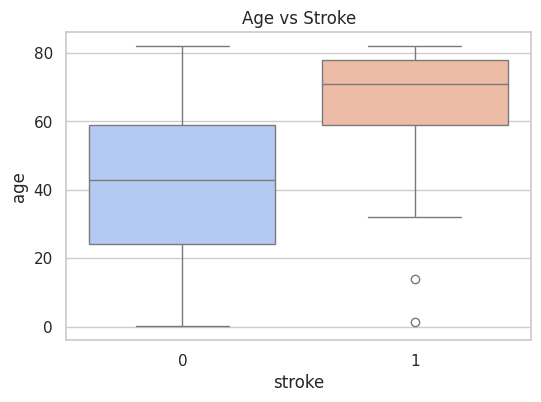

In [2]:
# Step 4 Data Visualization

# Scatter Plot: Age vs Average Glucose Level
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke', data=df, palette='coolwarm')
plt.title('Age vs Average Glucose Level by Stroke Outcome')
plt.show()

# Histogram: BMI Distribution
plt.figure(figsize=(7,5))
plt.hist(df['bmi'].dropna(), bins=20, color='lightblue', edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

# Bar Chart: Stroke Frequency by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='stroke', data=df, palette='pastel')
plt.title('Stroke Distribution by Gender')
plt.show()

# Box Plot: Age vs Stroke
plt.figure(figsize=(6,4))
sns.boxplot(x='stroke', y='age', data=df, palette='coolwarm')
plt.title('Age vs Stroke')
plt.show()



In [3]:
# Step 5 Data Preprocessing

# (1) Handle Missing Values
print("Missing values before cleaning:\n", df.isnull().sum())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print("Missing values after cleaning:\n", df.isnull().sum())

# (2) Outlier Detection using IQR
Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['avg_glucose_level'] < lower_bound) | (df['avg_glucose_level'] > upper_bound)]
print(f"Number of glucose outliers: {len(outliers)}")

# Remove outliers
df_clean = df[(df['avg_glucose_level'] >= lower_bound) & (df['avg_glucose_level'] <= upper_bound)]
print("Dataset after outlier removal:", df_clean.shape)

# (3) Data Reduction
# Drop the 'id' column (irrelevant) and take a 70% sample
df_reduced = df_clean.drop(columns=['id']).sample(frac=0.7, random_state=42)
print("Reduced dataset shape:", df_reduced.shape)

# (4) Data Scaling and Discretization
scaler = MinMaxScaler()
df_reduced[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(df_reduced[['age', 'avg_glucose_level', 'bmi']])

# Discretize 'age' into groups
df_reduced['age_group'] = pd.cut(df_reduced['age'], bins=4, labels=['Young', 'Adult', 'Middle-Aged', 'Senior'])

df_reduced.head()



Missing values before cleaning:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Missing values after cleaning:
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Number of glucose outliers: 627
Dataset after outlier removal: (4483, 12)
Reduced dataset shape: (3138, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
238,Female,0.621582,1,0,Yes,Private,Urban,0.291300,0.198146,never smoked,1,Middle-Aged
4537,Female,0.621582,0,0,Yes,Govt_job,Urban,0.231243,0.264195,smokes,0,Middle-Aged
1208,Female,0.499512,0,0,Yes,Private,Rural,0.458436,0.133256,never smoked,0,Adult
1318,Male,0.609375,0,1,No,Private,Urban,0.270342,0.238702,never smoked,0,Middle-Aged
891,Female,0.658203,0,0,Yes,Private,Rural,0.315252,0.206257,never smoked,0,Middle-Aged


<class 'pandas.core.frame.DataFrame'>
Index: 3138 entries, 238 to 1530
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             3138 non-null   object  
 1   age                3138 non-null   float64 
 2   hypertension       3138 non-null   int64   
 3   heart_disease      3138 non-null   int64   
 4   ever_married       3138 non-null   object  
 5   work_type          3138 non-null   object  
 6   Residence_type     3138 non-null   object  
 7   avg_glucose_level  3138 non-null   float64 
 8   bmi                3138 non-null   float64 
 9   smoking_status     3138 non-null   object  
 10  stroke             3138 non-null   int64   
 11  age_group          3138 non-null   category
dtypes: category(1), float64(3), int64(3), object(5)
memory usage: 297.5+ KB

Central Tendency Measures:
Mean:
 age                  0.497884
avg_glucose_level    0.322197
bmi                  0.197162
dtype: f

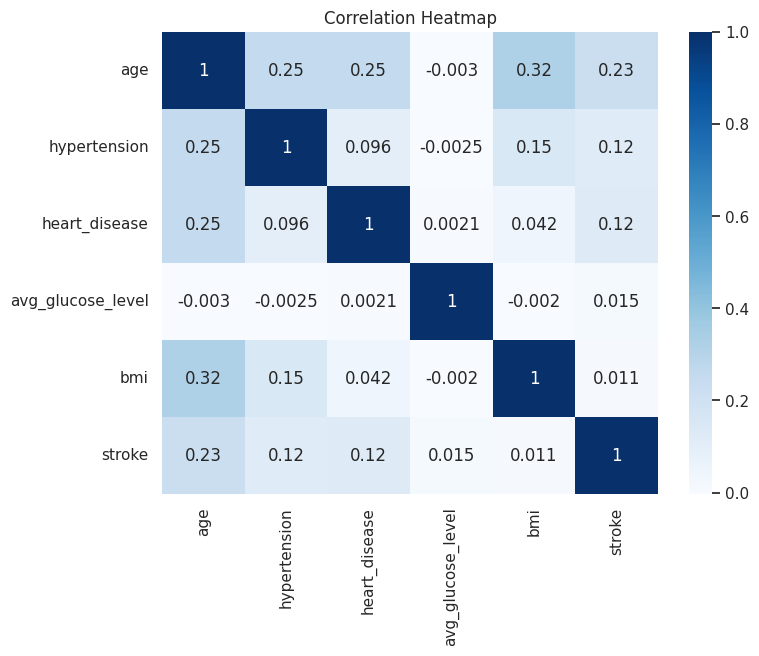

In [4]:
# Step 6Statistical Analysis

# (1) General Overview
df_reduced.info()
df_reduced.describe()

# (2) Central Tendency
mean_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].mean()
median_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].median()
mode_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].mode().iloc[0]
print("\nCentral Tendency Measures:")
print("Mean:\n", mean_values)
print("Median:\n", median_values)
print("Mode:\n", mode_values)

# (3) Dispersion Measures
range_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].max() - df_reduced[['age', 'avg_glucose_level', 'bmi']].min()
variance_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].var()
std_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].std()
IQR_values = df_reduced[['age', 'avg_glucose_level', 'bmi']].quantile(0.75) - df_reduced[['age', 'avg_glucose_level', 'bmi']].quantile(0.25)

print("\nDispersion Measures:")
print("Range:\n", range_values)
print("Variance:\n", variance_values)
print("Standard Deviation:\n", std_values)
print("IQR:\n", IQR_values)

# (4) Correlation Analysis
corr_matrix = df_reduced.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()